---
title: "Lab-4.1: Text Classification"
author: "Jorge Bris Moreno"
format:
  html:
    embed-resources: true
    code-fold: true
---

## Lab-4.1: Text classification

**Submission:**

* You need to upload ONE document to Canvas when you are done
  * (1) A PDF (or HTML) of the completed form of this notebook 
* The final uploaded version should NOT have any code-errors present 
* All outputs must be visible in the uploaded version, including code-cell outputs, images, graphs, etc

**Instructions** 

* In a Jupyter notebook named `lab-4.1.ipynb`
  * Train both an LSTM and a GRU on the IMDB dataset
  * Split the data into training, test, cross validation 
  * manually tune the hyper-parameters and ANN architecture to get the highest accuracy that you can
  * **You only need to do this week's example with Keras (i.e. no PyTorch)**
  * Normalize the data as needed
  * Visualize the results at the end where possible
  * Partition data into training, validation, and test
  * Monitor training and validation throughout training by plotting
  * Print training, validation, and test errors at the very end
  * You `MUST` use early stopping: [click here](https://keras.io/api/callbacks/early_stopping/)
  * Do `MANUAL` hyper parameter tuning to try to achieve an optimal fit model
    * i.e. best training/validation loss without over-fitting
    * Explore L1 and L2 regularization and dropout
    * Explore different optimizers 
    * Use the loss functions specified in the textbook
    * Explore different options for activation functions, network size/depth, etc
* **Document what is going on in the code, as needed, with narrative markdown text between cells.**
* *Submit the version with hyper parameters that provide the optimal fit*
  * i.e. you don't need to show the outputs of your hyper-parameter tuning process
  * See the Chollet textbook for reference code


## Libraries

Here we load the libraries we will use:

In [126]:
# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.datasets import imdb
from keras import preprocessing
import numpy as np
from keras.models import Sequential 
from keras import layers
import matplotlib.pyplot as plt
from keras.optimizers import RMSprop
from keras.callbacks import ReduceLROnPlateau
from keras.optimizers import Adam
from sklearn.model_selection import KFold
from keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l1_l2

## Params

Now, we are setting the parameters that will be later used in our models:

In [127]:
max_features = 10000 
batch_size   = 1000   
maxlen       = 250      
verbose      = 1
embed_dim    = 16    
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=4, verbose=1, factor=0.2, min_lr=1e-6)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, verbose=1)

## Data

This code obtained from professor's notebook loads the IMDB dataset and splits it into training, validation, and test sets:

In [128]:
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)
print(x_train[0][0:10]) # ,y_train.shape)

#truncating='pre' --> KEEPS THE LAST 20 WORDS
#truncating='post' --> KEEPS THE FIRST 20 WORDS
x_train = preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen,truncating='post')
x_test = preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen,truncating='post')
# print('input_train shape:', x_train.shape)
print(x_train[0][0:10]) # ,y_train.shape)
# print('input_train shape:', x_train.shape)

#PARTITION DATA
rand_indices = np.random.permutation(x_train.shape[0])
CUT=int(0.8*x_train.shape[0]); 
train_idx, val_idx = rand_indices[:CUT], rand_indices[CUT:]
x_val=x_train[val_idx]; y_val=y_train[val_idx]
x_train=x_train[train_idx]; y_train=y_train[train_idx]
print('input_train shape:', x_train.shape)

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65]
[0 0 0 0 0 0 0 0 0 0]
input_train shape: (20000, 250)


## LSTM

Here we are compiling a simple LSTM model with the following architecture:

In [129]:
# create model LSTM
model = Sequential() 
model.add(layers.Embedding(max_features, embed_dim, input_length=maxlen))
model.add(layers.LSTM(32, dropout= 0.1, recurrent_dropout= 0.5, kernel_regularizer=l1_l2(l1=0, l2=0)))
model.add(layers.Dense(1, activation='sigmoid', kernel_regularizer=l1_l2(l1=1e-5, l2=0)))
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential_24"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_17 (Embedding)    (None, 250, 16)           160000    
                                                                 
 lstm_18 (LSTM)              (None, 32)                6272      
                                                                 
 dense_23 (Dense)            (None, 1)                 33        
                                                                 
Total params: 166305 (649.63 KB)
Trainable params: 166305 (649.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Now, we will train it (we are printing the process to ensure the progress is being made):

In [130]:
# train model with training and validation set
history = model.fit(x_train, y_train, epochs=100, batch_size=batch_size, validation_data=(x_val, y_val), verbose=verbose, callbacks=[reduce_lr, early_stopping])

Epoch 1/100
20/20 [==============================] - 15s 666ms/step - loss: 0.6932 - accuracy: 0.5030 - val_loss: 0.6933 - val_accuracy: 0.4918 - lr: 1.0000e-04
Epoch 2/100
20/20 [==============================] - 12s 612ms/step - loss: 0.6929 - accuracy: 0.5145 - val_loss: 0.6931 - val_accuracy: 0.4952 - lr: 1.0000e-04
Epoch 3/100
20/20 [==============================] - 13s 638ms/step - loss: 0.6926 - accuracy: 0.5318 - val_loss: 0.6929 - val_accuracy: 0.5164 - lr: 1.0000e-04
Epoch 4/100
20/20 [==============================] - 13s 647ms/step - loss: 0.6922 - accuracy: 0.5481 - val_loss: 0.6925 - val_accuracy: 0.5294 - lr: 1.0000e-04
Epoch 5/100
20/20 [==============================] - 13s 657ms/step - loss: 0.6916 - accuracy: 0.5659 - val_loss: 0.6920 - val_accuracy: 0.5442 - lr: 1.0000e-04
Epoch 6/100
20/20 [==============================] - 13s 659ms/step - loss: 0.6908 - accuracy: 0.5895 - val_loss: 0.6912 - val_accuracy: 0.5662 - lr: 1.0000e-04
Epoch 7/100
20/20 [===============

Now, let's explore the training and validation on a plot:

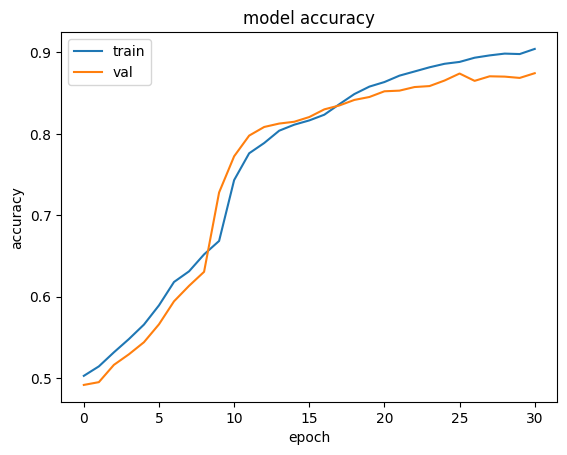

In [131]:
# Plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

The model seems to have a good fit for training and validation data, so now we will evaluate it on the test set to see how well our model generalizes to unseen data:

In [132]:
# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=2)

print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

782/782 - 15s - loss: 0.4207 - accuracy: 0.8468 - 15s/epoch - 19ms/step
Test Loss: 0.4207
Test Accuracy: 0.8468


We will use this and compare it to the GRU model.

## GRU

Here we are compiling a simple GRU model with the following architecture:

In [133]:
# create model LSTM
model = Sequential() 
model.add(layers.Embedding(max_features, embed_dim, input_length=maxlen))
model.add(layers.GRU(64, dropout= 0.1, recurrent_dropout= 0.5, kernel_regularizer=l1_l2(l1=0, l2=0))) 
model.add(layers.Dense(1, activation='sigmoid', kernel_regularizer=l1_l2(l1=1e-5, l2=0)))
model.compile(optimizer=Adam(learning_rate=1e-3), loss='binary_crossentropy', metrics=['acc']) 
model.summary()

Model: "sequential_25"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_18 (Embedding)    (None, 250, 16)           160000    
                                                                 
 gru_6 (GRU)                 (None, 64)                15744     
                                                                 
 dense_24 (Dense)            (None, 1)                 65        
                                                                 
Total params: 175809 (686.75 KB)
Trainable params: 175809 (686.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Now, we will train it (we are printing the process to ensure the progress is being made):

In [134]:
# train model with training and validation set
history = model.fit(x_train, y_train, epochs=50, batch_size=batch_size, validation_data=(x_val, y_val), verbose=verbose, callbacks=[reduce_lr, early_stopping])

Epoch 1/50
20/20 [==============================] - 20s 889ms/step - loss: 0.6919 - acc: 0.5342 - val_loss: 0.6897 - val_acc: 0.5388 - lr: 0.0010
Epoch 2/50
20/20 [==============================] - 17s 865ms/step - loss: 0.6703 - acc: 0.6256 - val_loss: 0.5996 - val_acc: 0.7212 - lr: 0.0010
Epoch 3/50
20/20 [==============================] - 19s 936ms/step - loss: 0.5100 - acc: 0.7646 - val_loss: 0.3972 - val_acc: 0.8314 - lr: 0.0010
Epoch 4/50
20/20 [==============================] - 19s 922ms/step - loss: 0.3792 - acc: 0.8408 - val_loss: 0.3612 - val_acc: 0.8472 - lr: 0.0010
Epoch 5/50
20/20 [==============================] - 18s 900ms/step - loss: 0.3162 - acc: 0.8740 - val_loss: 0.3323 - val_acc: 0.8602 - lr: 0.0010
Epoch 6/50
20/20 [==============================] - 17s 852ms/step - loss: 0.2679 - acc: 0.8978 - val_loss: 0.3089 - val_acc: 0.8744 - lr: 0.0010
Epoch 7/50
20/20 [==============================] - 17s 849ms/step - loss: 0.2345 - acc: 0.9143 - val_loss: 0.3124 - val_acc

Now, let's explore the training and validation on a plot:

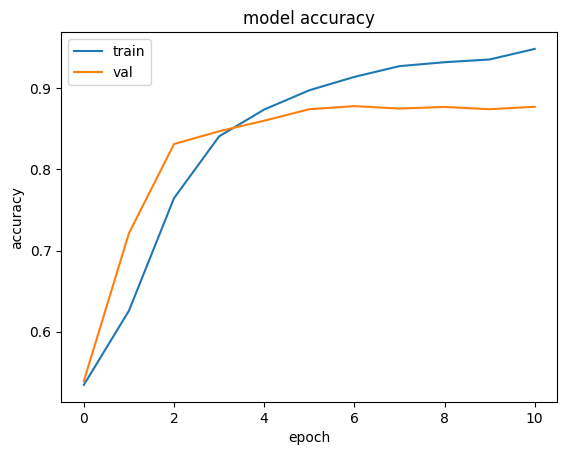

In [141]:
# Plot
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

The model seems to have a good fit for training and validation data, so now we will evaluate it on the test set to see how well our model generalizes to unseen data:

In [142]:
# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=2)

print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

782/782 - 15s - loss: 0.3914 - acc: 0.8582 - 15s/epoch - 19ms/step
Test Loss: 0.3914
Test Accuracy: 0.8582


This accruacy is very similar to the one obtained with the LSTM model, which is expected since both models are very similar in terms of architecture and hyperparameters.